# Soweto Climate Data Analysis

This notebook provides interactive exploration of the extracted climate data.

**Prerequisites**: Run `soweto_climate_pipeline.py` first to generate the data files.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Data directory
DATA_DIR = Path('climate_data_output')

print("Setup complete!")

Setup complete!


## 1. Load Data

In [2]:
# Load raw data
temp_raw = pd.read_csv(DATA_DIR / 'soweto_temperature_raw.csv')
temp_raw['date'] = pd.to_datetime(temp_raw['date'])

pm25_raw = pd.read_csv(DATA_DIR / 'soweto_pm25_raw.csv')
pm25_raw['date'] = pd.to_datetime(pm25_raw['date'])

# Load aggregated data
temp_monthly = pd.read_csv(DATA_DIR / 'soweto_temp_monthly_stats.csv')
temp_seasonal = pd.read_csv(DATA_DIR / 'soweto_temp_seasonal_stats.csv')
temp_annual = pd.read_csv(DATA_DIR / 'soweto_temp_annual_stats.csv')

pm25_monthly = pd.read_csv(DATA_DIR / 'soweto_pm25_monthly_stats.csv')
pm25_seasonal = pd.read_csv(DATA_DIR / 'soweto_pm25_seasonal_stats.csv')
pm25_annual = pd.read_csv(DATA_DIR / 'soweto_pm25_annual_stats.csv')

# Load quality report
with open(DATA_DIR / 'quality_report.json', 'r') as f:
    quality_report = json.load(f)

print(f"Temperature records: {len(temp_raw):,}")
print(f"PM2.5 records: {len(pm25_raw):,}")
print(f"\nDate range: {temp_raw['date'].min()} to {temp_raw['date'].max()}")

Temperature records: 96,408
PM2.5 records: 248,654

Date range: 2014-01-01 00:00:00 to 2024-12-30 23:00:00


## 2. Quality Report Summary

In [3]:
print("="*80)
print("QUALITY REPORT SUMMARY")
print("="*80)

print("\nTemperature Data:")
for key, value in quality_report['temperature'].items():
    print(f"  {key}: {value}")

print("\nPM2.5 Data:")
for key, value in quality_report['pm25'].items():
    print(f"  {key}: {value}")

print("\nPipeline Information:")
for key, value in quality_report['pipeline_info'].items():
    print(f"  {key}: {value}")

QUALITY REPORT SUMMARY

Temperature Data:
  variable: temperature_c
  total_records: 96408
  missing_values: 0
  missing_percentage: 0.0
  outlier_count: 0
  date_range_actual: 2014-01-01 00:00:00 to 2024-12-30 23:00:00
  date_range_expected: 2014-01-01 00:00:00 to 2024-12-31 00:00:00
  min_value: -3.7625688340928605
  max_value: 36.71637437608507
  mean_value: 16.545981724245305
  status: PASSED

PM2.5 Data:
  variable: pm25
  total_records: 248654
  missing_values: 574
  missing_percentage: 0.23084285794718767
  outlier_count: 18127
  date_range_actual: 2016-06-22 12:00:00 to 2024-12-30 21:00:00
  date_range_expected: 2014-01-01 00:00:00 to 2024-12-31 00:00:00
  min_value: 0.0
  max_value: 1.2807790050409005e-06
  mean_value: 4.892003271344923e-08
  status: PASSED

Pipeline Information:
  execution_date: 2026-02-09T17:00:10.758166
  location: Soweto (-26.2678, 27.8585)
  buffer_distance_m: 5000
  date_range: 2014-01-01 to 2024-12-31
  data_sources: {'temperature': 'ECMWF/ERA5_LAND/HO

## 3. Temperature Analysis

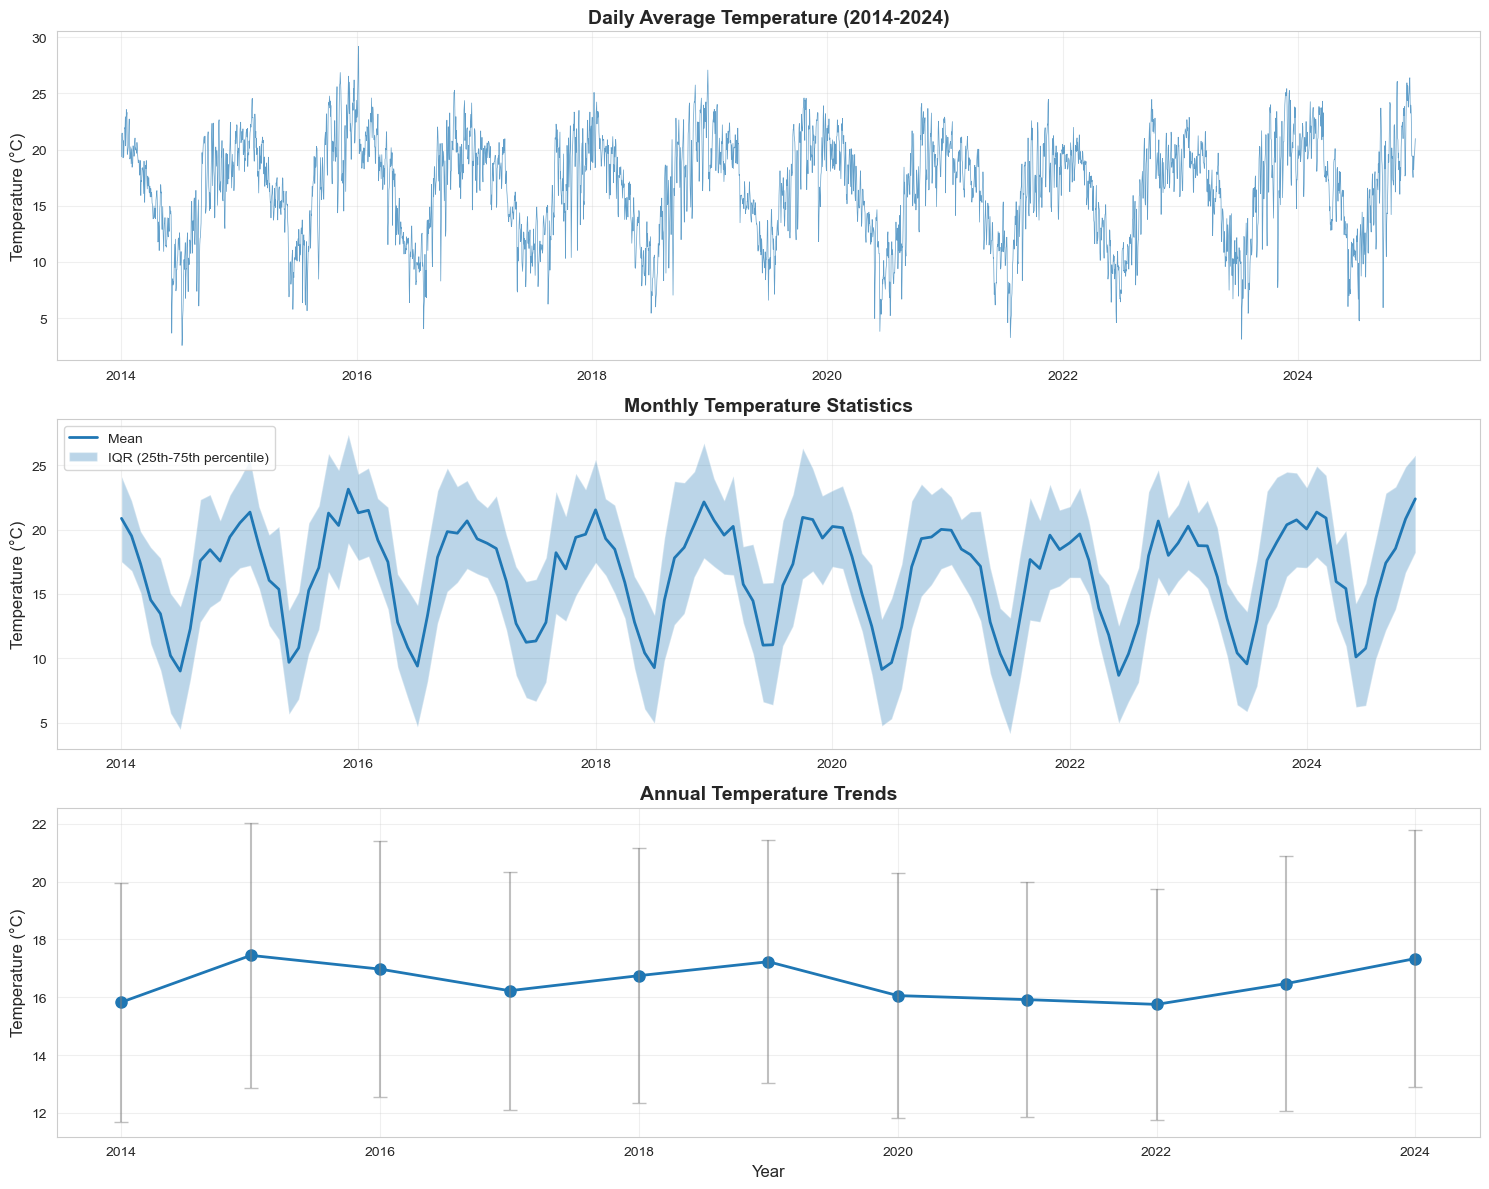

Annual temperature range: 15.8°C - 17.4°C


In [4]:
# Temperature time series (daily averages for visualization)
temp_daily = temp_raw.set_index('date').resample('D')['temperature_c'].mean()

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Raw time series
axes[0].plot(temp_daily.index, temp_daily.values, linewidth=0.5, alpha=0.7)
axes[0].set_title('Daily Average Temperature (2014-2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Temperature (°C)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Monthly statistics
temp_monthly['date'] = pd.to_datetime(temp_monthly[['year', 'month']].assign(day=1))
axes[1].plot(temp_monthly['date'], temp_monthly['temperature_c_mean'], label='Mean', linewidth=2)
axes[1].fill_between(temp_monthly['date'], 
                      temp_monthly['temperature_c_q25'], 
                      temp_monthly['temperature_c_q75'],
                      alpha=0.3, label='IQR (25th-75th percentile)')
axes[1].set_title('Monthly Temperature Statistics', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Temperature (°C)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Annual statistics
axes[2].plot(temp_annual['year'], temp_annual['temperature_c_mean'], marker='o', linewidth=2, markersize=8)
axes[2].errorbar(temp_annual['year'], temp_annual['temperature_c_mean'], 
                 yerr=temp_annual['temperature_c_iqr']/2, 
                 fmt='none', ecolor='gray', alpha=0.5, capsize=5)
axes[2].set_title('Annual Temperature Trends', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Year', fontsize=12)
axes[2].set_ylabel('Temperature (°C)', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'temperature_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Annual temperature range: {temp_annual['temperature_c_mean'].min():.1f}°C - {temp_annual['temperature_c_mean'].max():.1f}°C")

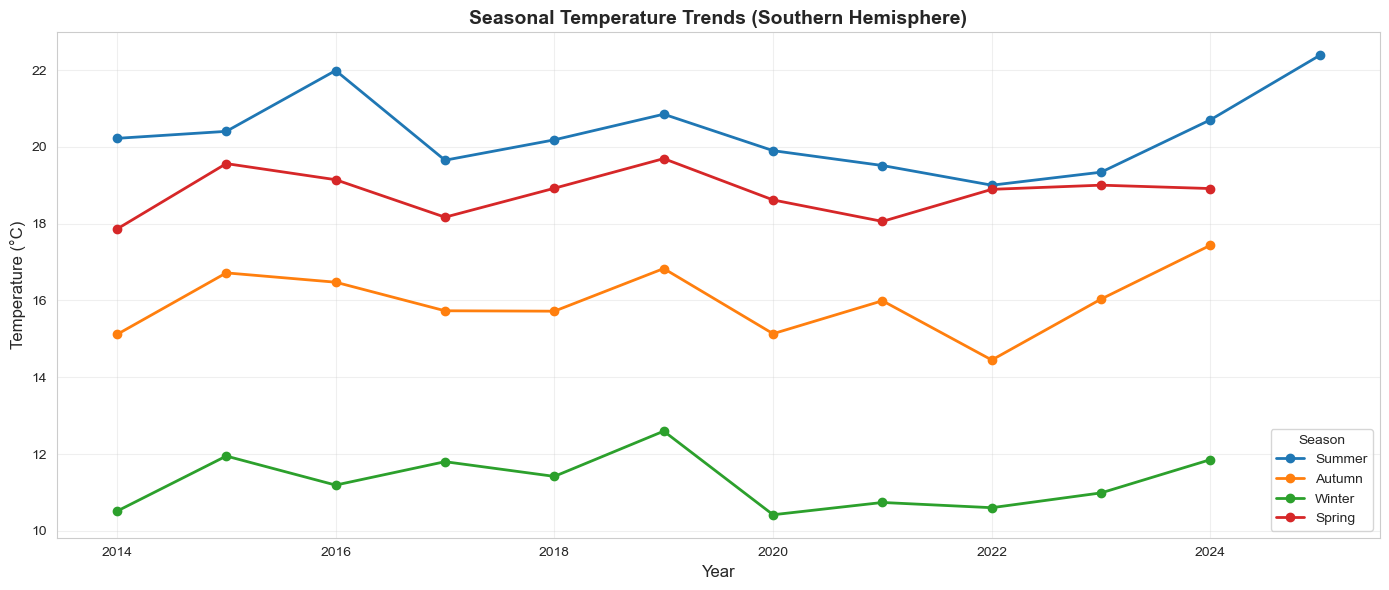

In [5]:
# Seasonal patterns
season_order = ['Summer', 'Autumn', 'Winter', 'Spring']
temp_seasonal['season'] = pd.Categorical(temp_seasonal['season'], categories=season_order, ordered=True)
temp_seasonal = temp_seasonal.sort_values(['season_year', 'season'])

fig, ax = plt.subplots(figsize=(14, 6))

for season in season_order:
    data = temp_seasonal[temp_seasonal['season'] == season]
    ax.plot(data['season_year'], data['temperature_c_mean'], marker='o', label=season, linewidth=2)

ax.set_title('Seasonal Temperature Trends (Southern Hemisphere)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.legend(title='Season', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'temperature_seasonal.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. PM2.5 Analysis

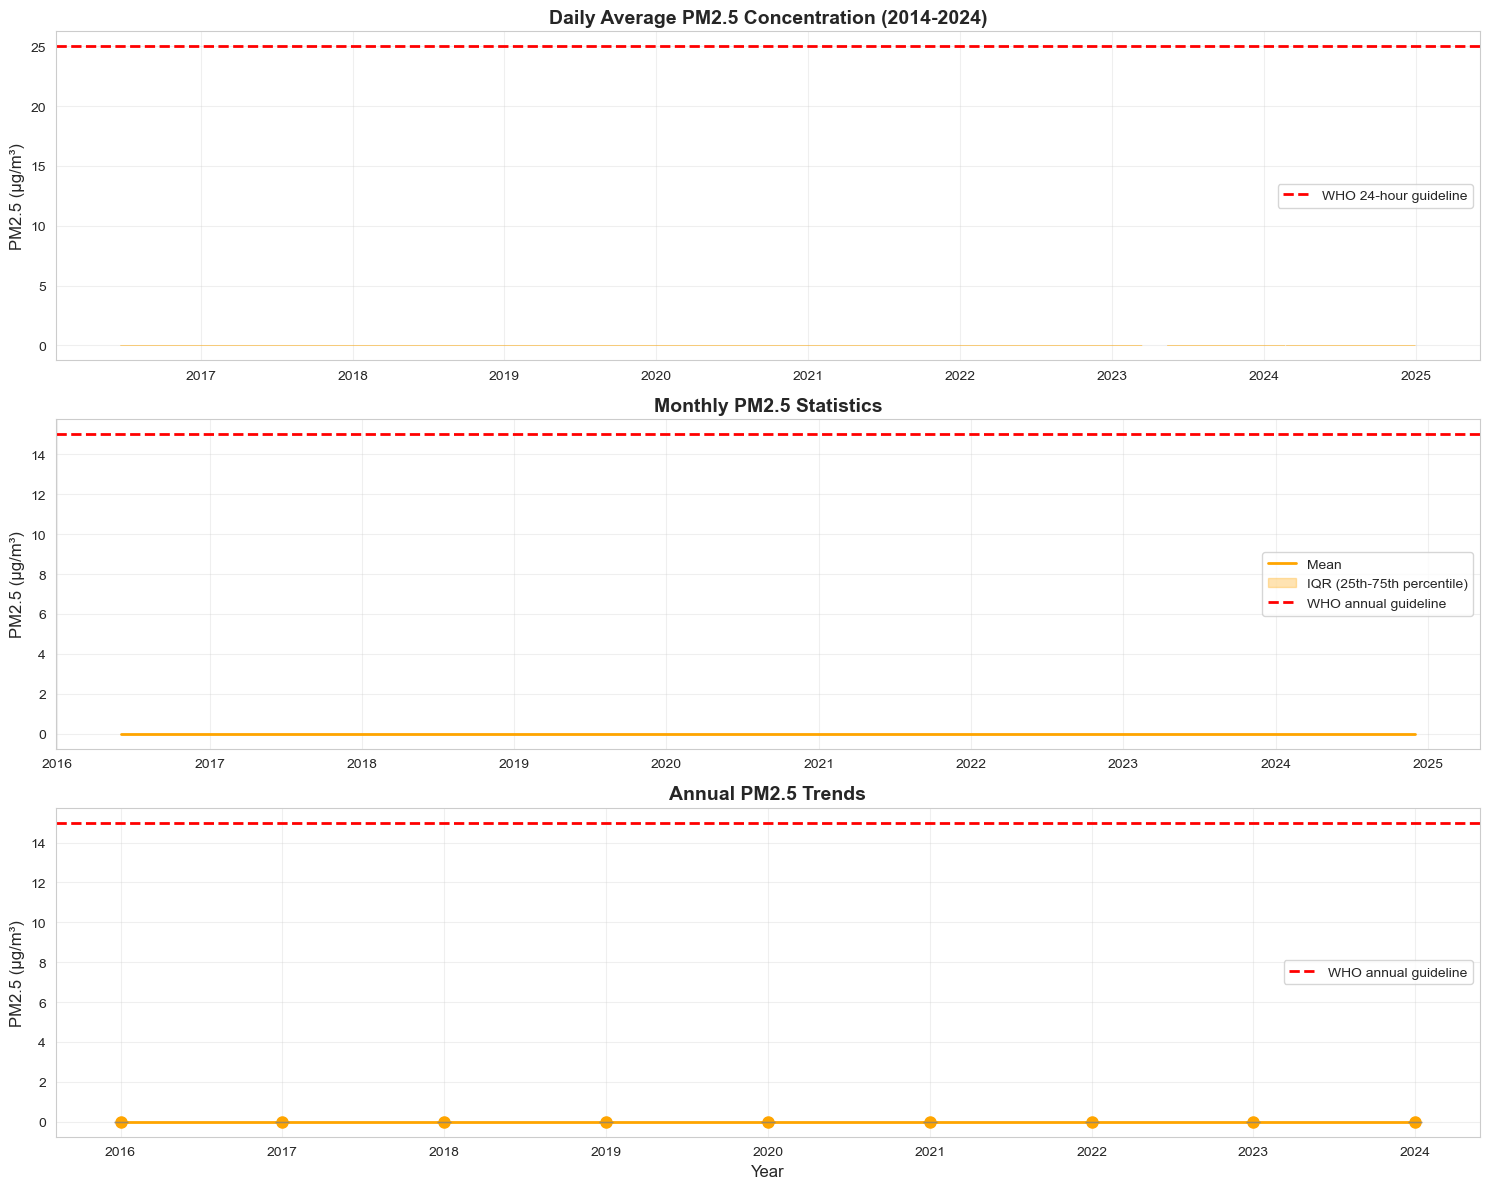

Annual PM2.5 range: 0.0 - 0.0 µg/m³
Years exceeding WHO guideline (15 µg/m³): 0/9


In [6]:
# PM2.5 time series (daily averages for visualization)
pm25_daily = pm25_raw.set_index('date').resample('D')['pm25'].mean()

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Raw time series
axes[0].plot(pm25_daily.index, pm25_daily.values, linewidth=0.5, alpha=0.7, color='orange')
axes[0].axhline(y=25, color='red', linestyle='--', linewidth=2, label='WHO 24-hour guideline')
axes[0].set_title('Daily Average PM2.5 Concentration (2014-2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('PM2.5 (µg/m³)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Monthly statistics
pm25_monthly['date'] = pd.to_datetime(pm25_monthly[['year', 'month']].assign(day=1))
axes[1].plot(pm25_monthly['date'], pm25_monthly['pm25_mean'], label='Mean', linewidth=2, color='orange')
axes[1].fill_between(pm25_monthly['date'], 
                      pm25_monthly['pm25_q25'], 
                      pm25_monthly['pm25_q75'],
                      alpha=0.3, label='IQR (25th-75th percentile)', color='orange')
axes[1].axhline(y=15, color='red', linestyle='--', linewidth=2, label='WHO annual guideline')
axes[1].set_title('Monthly PM2.5 Statistics', fontsize=14, fontweight='bold')
axes[1].set_ylabel('PM2.5 (µg/m³)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Annual statistics
axes[2].plot(pm25_annual['year'], pm25_annual['pm25_mean'], marker='o', linewidth=2, markersize=8, color='orange')
axes[2].errorbar(pm25_annual['year'], pm25_annual['pm25_mean'], 
                 yerr=pm25_annual['pm25_iqr']/2, 
                 fmt='none', ecolor='gray', alpha=0.5, capsize=5)
axes[2].axhline(y=15, color='red', linestyle='--', linewidth=2, label='WHO annual guideline')
axes[2].set_title('Annual PM2.5 Trends', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Year', fontsize=12)
axes[2].set_ylabel('PM2.5 (µg/m³)', fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'pm25_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Annual PM2.5 range: {pm25_annual['pm25_mean'].min():.1f} - {pm25_annual['pm25_mean'].max():.1f} µg/m³")
print(f"Years exceeding WHO guideline (15 µg/m³): {(pm25_annual['pm25_mean'] > 15).sum()}/{len(pm25_annual)}")

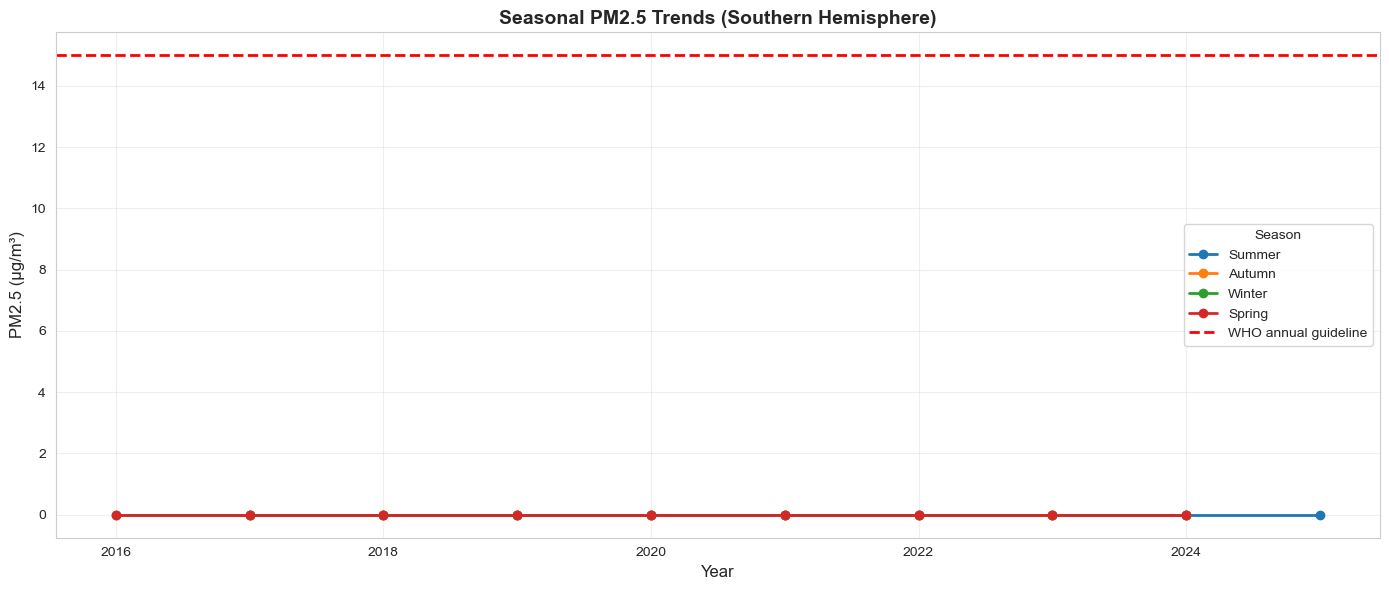

In [7]:
# Seasonal PM2.5 patterns
pm25_seasonal['season'] = pd.Categorical(pm25_seasonal['season'], categories=season_order, ordered=True)
pm25_seasonal = pm25_seasonal.sort_values(['season_year', 'season'])

fig, ax = plt.subplots(figsize=(14, 6))

for season in season_order:
    data = pm25_seasonal[pm25_seasonal['season'] == season]
    ax.plot(data['season_year'], data['pm25_mean'], marker='o', label=season, linewidth=2)

ax.axhline(y=15, color='red', linestyle='--', linewidth=2, label='WHO annual guideline')
ax.set_title('Seasonal PM2.5 Trends (Southern Hemisphere)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('PM2.5 (µg/m³)', fontsize=12)
ax.legend(title='Season', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'pm25_seasonal.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Combined Analysis

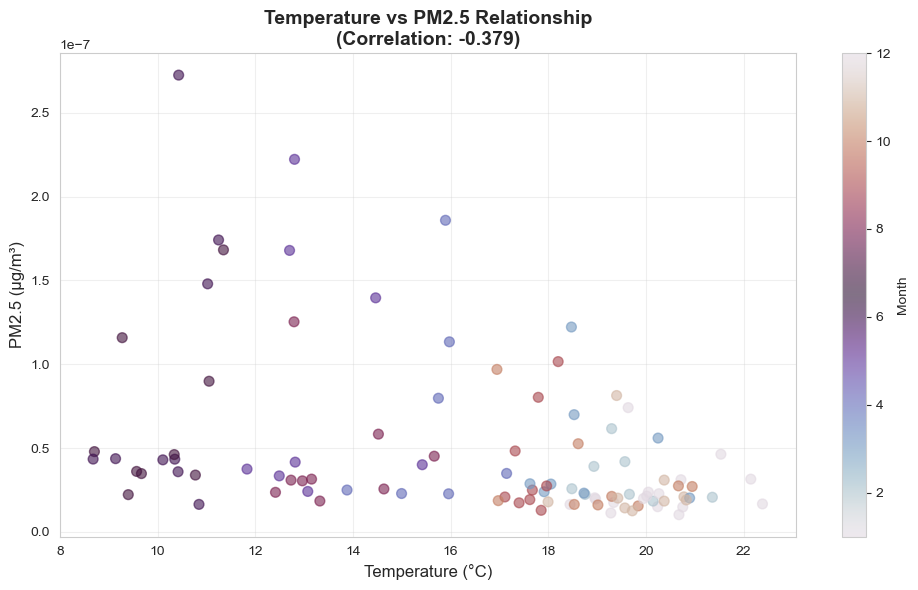

Correlation coefficient: -0.379


In [8]:
# Correlation between temperature and PM2.5
# Merge monthly data
combined_monthly = pd.merge(
    temp_monthly[['year', 'month', 'temperature_c_mean']],
    pm25_monthly[['year', 'month', 'pm25_mean']],
    on=['year', 'month']
)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(combined_monthly['temperature_c_mean'], 
                     combined_monthly['pm25_mean'],
                     c=combined_monthly['month'], 
                     cmap='twilight', 
                     s=50, 
                     alpha=0.6)

# Calculate correlation
correlation = combined_monthly['temperature_c_mean'].corr(combined_monthly['pm25_mean'])

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('PM2.5 (µg/m³)', fontsize=12)
ax.set_title(f'Temperature vs PM2.5 Relationship\n(Correlation: {correlation:.3f})', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Month', fontsize=10)

plt.tight_layout()
plt.savefig(DATA_DIR / 'temp_pm25_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Correlation coefficient: {correlation:.3f}")

## 6. Summary Statistics

In [9]:
print("="*80)
print("SUMMARY STATISTICS (2014-2024)")
print("="*80)

print("\nTemperature (°C):")
print(f"  Overall mean: {temp_raw['temperature_c'].mean():.2f}")
print(f"  Overall median: {temp_raw['temperature_c'].median():.2f}")
print(f"  Overall range: {temp_raw['temperature_c'].min():.2f} to {temp_raw['temperature_c'].max():.2f}")
print(f"  Standard deviation: {temp_raw['temperature_c'].std():.2f}")

print("\nPM2.5 (µg/m³):")
print(f"  Overall mean: {pm25_raw['pm25'].mean():.2f}")
print(f"  Overall median: {pm25_raw['pm25'].median():.2f}")
print(f"  Overall range: {pm25_raw['pm25'].min():.2f} to {pm25_raw['pm25'].max():.2f}")
print(f"  Standard deviation: {pm25_raw['pm25'].std():.2f}")

print("\nAnnual Trends:")
temp_trend = np.polyfit(temp_annual['year'], temp_annual['temperature_c_mean'], 1)[0]
pm25_trend = np.polyfit(pm25_annual['year'], pm25_annual['pm25_mean'], 1)[0]
print(f"  Temperature trend: {temp_trend:.4f} °C/year")
print(f"  PM2.5 trend: {pm25_trend:.4f} µg/m³/year")

print("\nSeasonal Averages:")
for season in season_order:
    temp_avg = temp_seasonal[temp_seasonal['season'] == season]['temperature_c_mean'].mean()
    pm25_avg = pm25_seasonal[pm25_seasonal['season'] == season]['pm25_mean'].mean()
    print(f"  {season}: Temp={temp_avg:.2f}°C, PM2.5={pm25_avg:.2f}µg/m³")

SUMMARY STATISTICS (2014-2024)

Temperature (°C):
  Overall mean: 16.55
  Overall median: 16.71
  Overall range: -3.76 to 36.72
  Standard deviation: 6.35

PM2.5 (µg/m³):
  Overall mean: 0.00
  Overall median: 0.00
  Overall range: 0.00 to 0.00
  Standard deviation: 0.00

Annual Trends:
  Temperature trend: -0.0122 °C/year
  PM2.5 trend: -0.0000 µg/m³/year

Seasonal Averages:
  Summer: Temp=20.35°C, PM2.5=0.00µg/m³
  Autumn: Temp=15.97°C, PM2.5=0.00µg/m³
  Winter: Temp=11.28°C, PM2.5=0.00µg/m³
  Spring: Temp=18.80°C, PM2.5=0.00µg/m³


## 7. Export Analysis Results

In [10]:
# Create comprehensive summary
summary = {
    'analysis_date': pd.Timestamp.now().isoformat(),
    'data_coverage': {
        'start_date': str(temp_raw['date'].min()),
        'end_date': str(temp_raw['date'].max()),
        'temperature_records': len(temp_raw),
        'pm25_records': len(pm25_raw)
    },
    'temperature_summary': {
        'mean_c': float(temp_raw['temperature_c'].mean()),
        'median_c': float(temp_raw['temperature_c'].median()),
        'min_c': float(temp_raw['temperature_c'].min()),
        'max_c': float(temp_raw['temperature_c'].max()),
        'std_c': float(temp_raw['temperature_c'].std()),
        'trend_c_per_year': float(temp_trend)
    },
    'pm25_summary': {
        'mean_ugm3': float(pm25_raw['pm25'].mean()),
        'median_ugm3': float(pm25_raw['pm25'].median()),
        'min_ugm3': float(pm25_raw['pm25'].min()),
        'max_ugm3': float(pm25_raw['pm25'].max()),
        'std_ugm3': float(pm25_raw['pm25'].std()),
        'trend_ugm3_per_year': float(pm25_trend),
        'years_exceeding_who_guideline': int((pm25_annual['pm25_mean'] > 15).sum())
    },
    'correlation': {
        'temp_pm25_monthly': float(correlation)
    }
}

with open(DATA_DIR / 'analysis_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Analysis summary saved to: climate_data_output/analysis_summary.json")
print("\nAll visualizations saved to climate_data_output/")

Analysis summary saved to: climate_data_output/analysis_summary.json

All visualizations saved to climate_data_output/
